<a href="https://colab.research.google.com/github/araoclaudio2-create/Assignment-AI-2/blob/main/Assignment_5_into_to_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Load the Titanic dataset
# TODO: Load the Titanic dataset from the following URL
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
# df = pd.read_csv('Titanic-Dataset.csv')

In [ ]:
# Task 2: Inspect the data
# Load the dataset within this cell to resolve NameError
df = pd.read_csv(url)

# TODO: Display the first 5 rows of the dataset
df.head()

# TODO: Display the last 5 rows of the dataset
# ... df.tail()

# TODO: Display the data types of each column
# ... df.dtypes

# TODO: Display summary statistics of the numerical columns
# ... df.describe()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [ ]:
# Task 3: Clean and preprocess the data

# TODO: Create a new categorical feature 'PclassCategory' from 'Pclass'
df['PclassCategory'] = df['Pclass'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')

# TODO: Create a new categorical feature 'CabinCategory' from 'Cabin'
# Note: The 'Cabin' column does not exist in the current DataFrame.
# If 'Cabin' were present, you would use:
# df['CabinCategory'] = df['Cabin'].astype('category')
# df['Cabin'] = df['Cabin'].astype('category')

# TODO: Handle missing values in the 'Age' column (use mean age)
df['Age'] = df['Age'].fillna(df['Age'].mean())

# TODO: Create a 'Family' feature by combining 'SibSp' and 'Parch'
# Using the correct column names from the DataFrame: 'Siblings/Spouses Aboard' and 'Parents/Children Aboard'
df['FamilySize'] = df['Siblings/Spouses Aboard'] + df['Parents/Children Aboard']

In [ ]:
# Task 4: Identify specific data points

# TODO: Find passengers with the highest fare
# highest_fare_passengers = ...

# TODO: Find passengers with the largest family size
# largest_family_passengers = ...

# Highest fare
df.loc[df['Fare'].idxmax()]

# Largest family
df.loc[df['FamilySize'].idxmax()]

,158
Survived,0
Pclass,3
Name,Master. Thomas Henry Sage
Sex,male
Age,5.0
Siblings/Spouses Aboard,8
Parents/Children Aboard,2
Fare,69.55
PclassCategory,3
FamilySize,10


In [ ]:
# Task 5: Demonstrate Pandas Series and DataFrame functionalities

# TODO: Create a Pandas Series of passenger names
# names_series = ...

# TODO: Create a DataFrame of passenger names and ages
# names_ages_df = ...

# TODO: Slice the DataFrame to show only passengers older than 50
# older_passengers = ...

# Create a Series
ages = pd.Series([22, 38, 26])

# Create a DataFrame
data = {
    'Name': ['A', 'B', 'C'],
    'Age': [22, 38, 26]
}
df2 = pd.DataFrame(data)

df['Age']          # select column
df.iloc[0:5]       # first 5 rows
df.loc[:, ['Age', 'Fare']]  # specific columns

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
882,27.0,13.0000
883,19.0,30.0000
884,7.0,23.4500
885,26.0,30.0000


In [ ]:
# Task 6: Introduce multi-indexing

# TODO: Create a multi-index DataFrame grouped by 'Sex' and 'Pclass'
# multi_index_df = ...

multi_index = df.groupby(['Sex', 'Pclass'])['Survived'].mean()
multi_index

/tmp/ipykernel_29963/3236977904.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  multi_index = df.groupby(['Sex', 'Pclass'])['Survived'].mean()


Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.137026
Name: Survived, dtype: float64

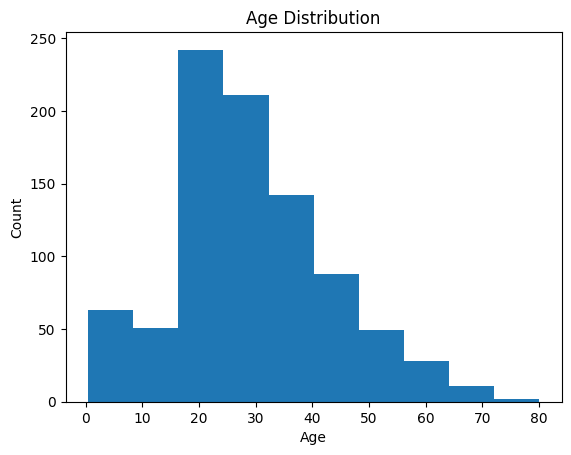

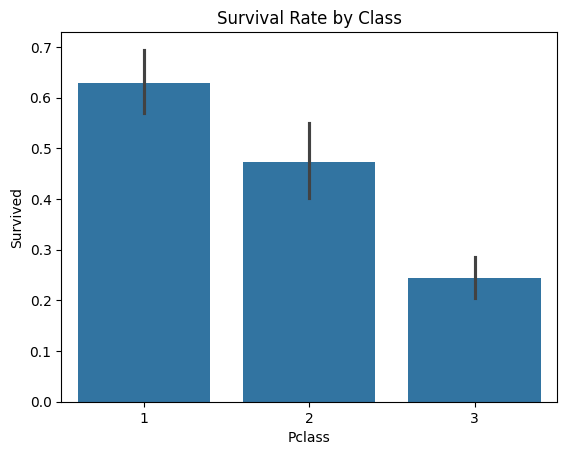

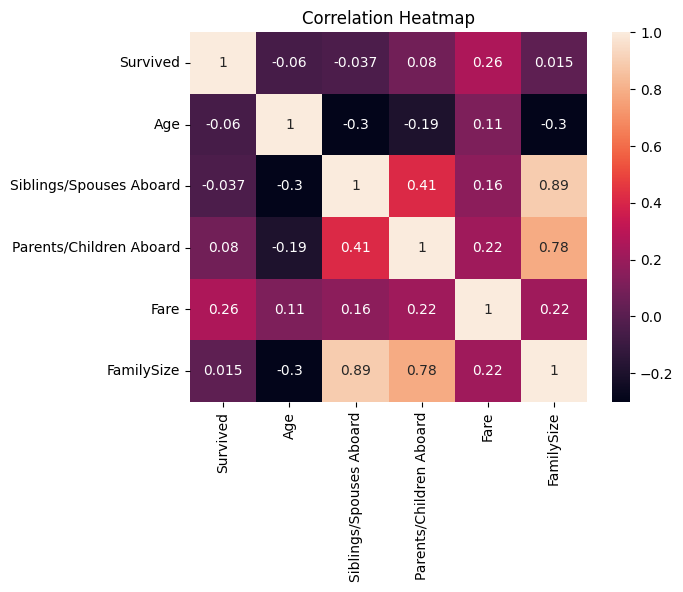

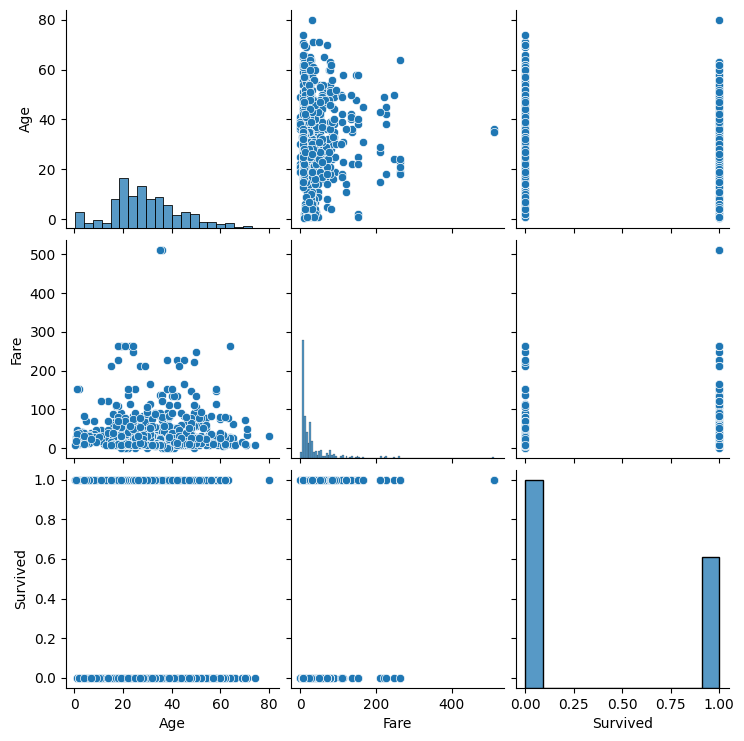

In [2]:
# Imports and df definition from previous cells to resolve NameError if not run
import pandas as pd
import numpy as np
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
df = pd.read_csv(url)

# Preprocessing steps from Task 3 (ensure df has required columns)
df['PclassCategory'] = df['Pclass'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['FamilySize'] = df['Siblings/Spouses Aboard'] + df['Parents/Children Aboard']

# Task 7: Visualizations

# TODO: Create a histogram of passenger ages
# plt.figure(figsize=(10, 6))
# ...
# plt.title('Histogram of Passenger Ages')
# plt.xlabel('Age')
# plt.ylabel('Count')
# plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

plt.hist(df['Age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# TODO: Create a bar plot of survival rates by passenger class
# ...
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')
plt.show()

# TODO: Create a heatmap of correlation between numerical features
# plt.figure(figsize=(12, 10))
# ...
# plt.title('Correlation Heatmap of Numerical Features')
# plt.show()

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

# TODO: Create a pair plot of 'Age', 'Fare', 'SibSp', and 'Parch', colored by 'Survived'
# ...

sns.pairplot(df[['Age', 'Fare', 'Survived']])
plt.show()

In [3]:
# Task 8: Analyze survival rates

# TODO: Calculate and display survival rates by sex
# survival_by_sex = ...

# TODO: Calculate and display survival rates by passenger class
# survival_by_class = ...

df.groupby('Sex')['Survived'].mean()
df.groupby('Pclass')['Survived'].mean()

/tmp/ipykernel_30000/2894771458.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Pclass')['Survived'].mean()


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.244353


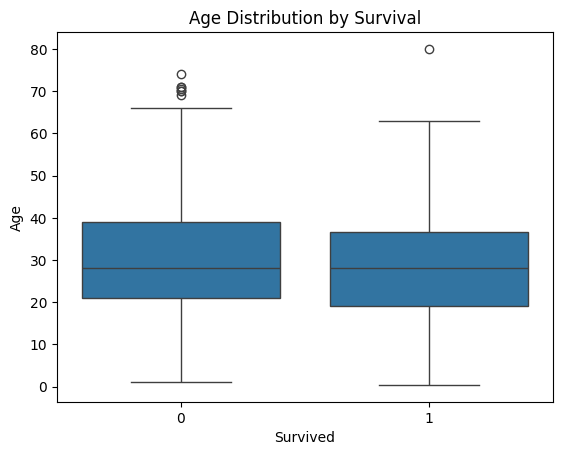

In [4]:
# Task 9: Analyze age distribution

# TODO: Create a box plot of age distribution by passenger class and sex
# plt.figure(figsize=(12, 6))
# ...
# plt.title('Age Distribution by Passenger Class and Sex')
# plt.show()

sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival')
plt.show()

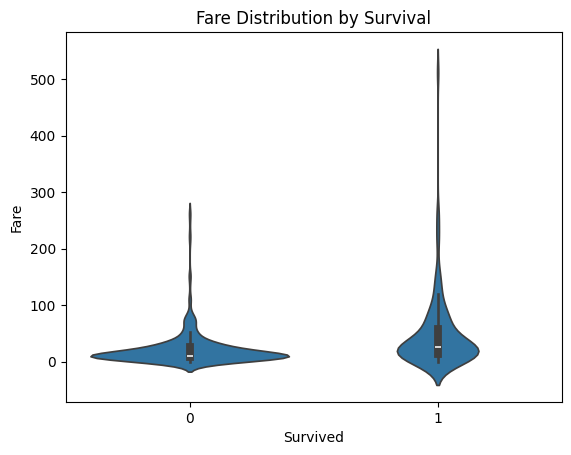

EDA tasks completed.


In [5]:
# Task 10: Analyze fare distribution

# TODO: Create a violin plot of fare distribution by passenger class and survival status
# plt.figure(figsize=(12, 6))
# ...
# plt.title('Fare Distribution by Passenger Class and Survival Status')
# plt.show()

sns.violinplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.show()

print("EDA tasks completed.")